In [ ]:
pip install pymupdf pandas nltk wordcloud matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 45.6 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 15.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/sumeyyepakdil/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sumeyyepakdil/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                 file               section  \
0   TARGET CORP files (10-K) Basic annual filing, ...              business   
1   TARGET CORP files (10-K) Basic annual filing, ...          risk_factors   
2   TARGET CORP files (10-K) Basic annual filing, ...                  md&a   
3   TARGET CORP files (10-K) Basic annual filing, ...  financial_statements   
4   TARGET CORP files (10-K) Basic annual filing, ...              business   
5   TARGET CORP files (10-K) Basic annual filing, ...          risk_factors   
6   TARGET CORP files (10-K) Basic annual filing, ...                  md&a   
7   TARGET CORP files (10-K) Basic annual filing, ...  financial_statements   
8   TARGET CORP files (10-K) Basic annual filing, ...              business   
9   TARGET CORP files (10-K) Basic annual filing, ...          risk_factors   
10  TARGET CORP files (10-K) Basic annual filing, ...                  md&a   
11  TARGET CORP files (10-K) Basic annual filing, ..

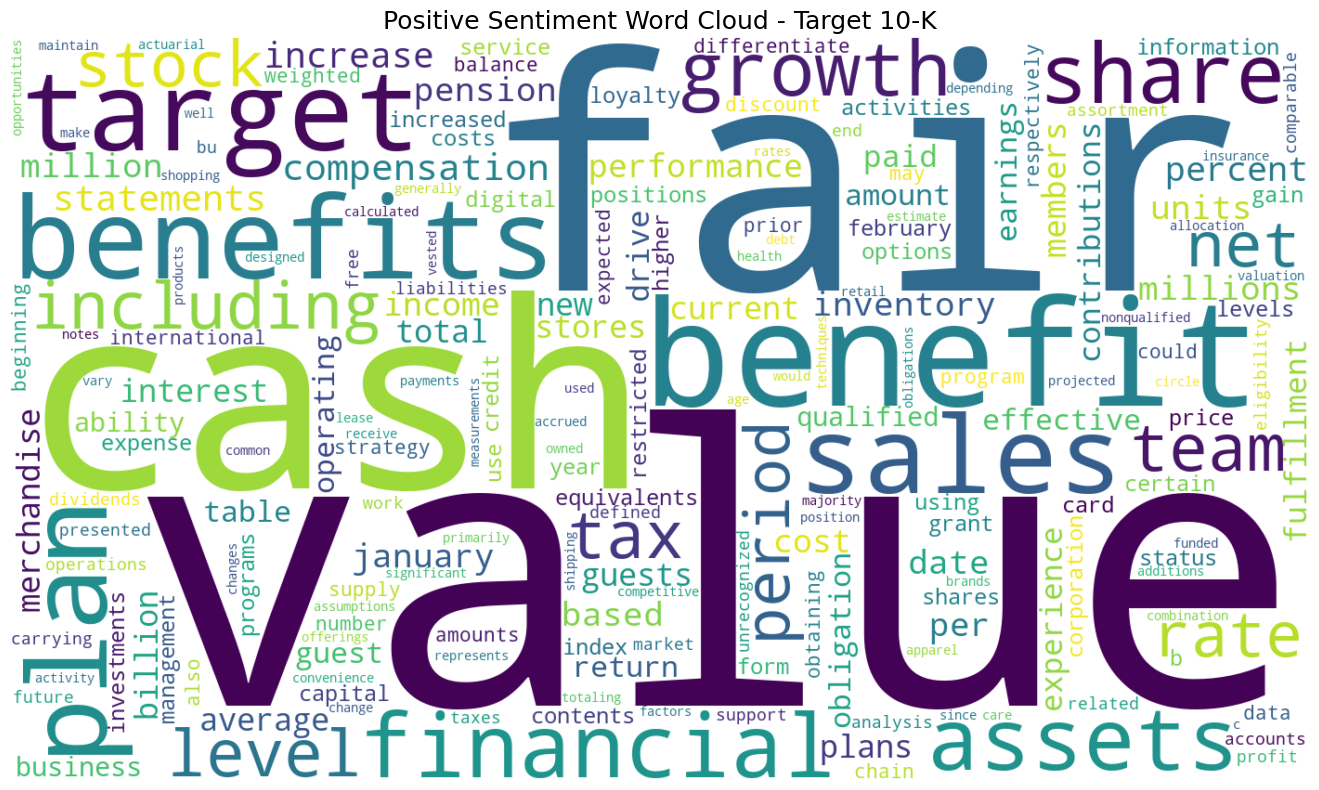

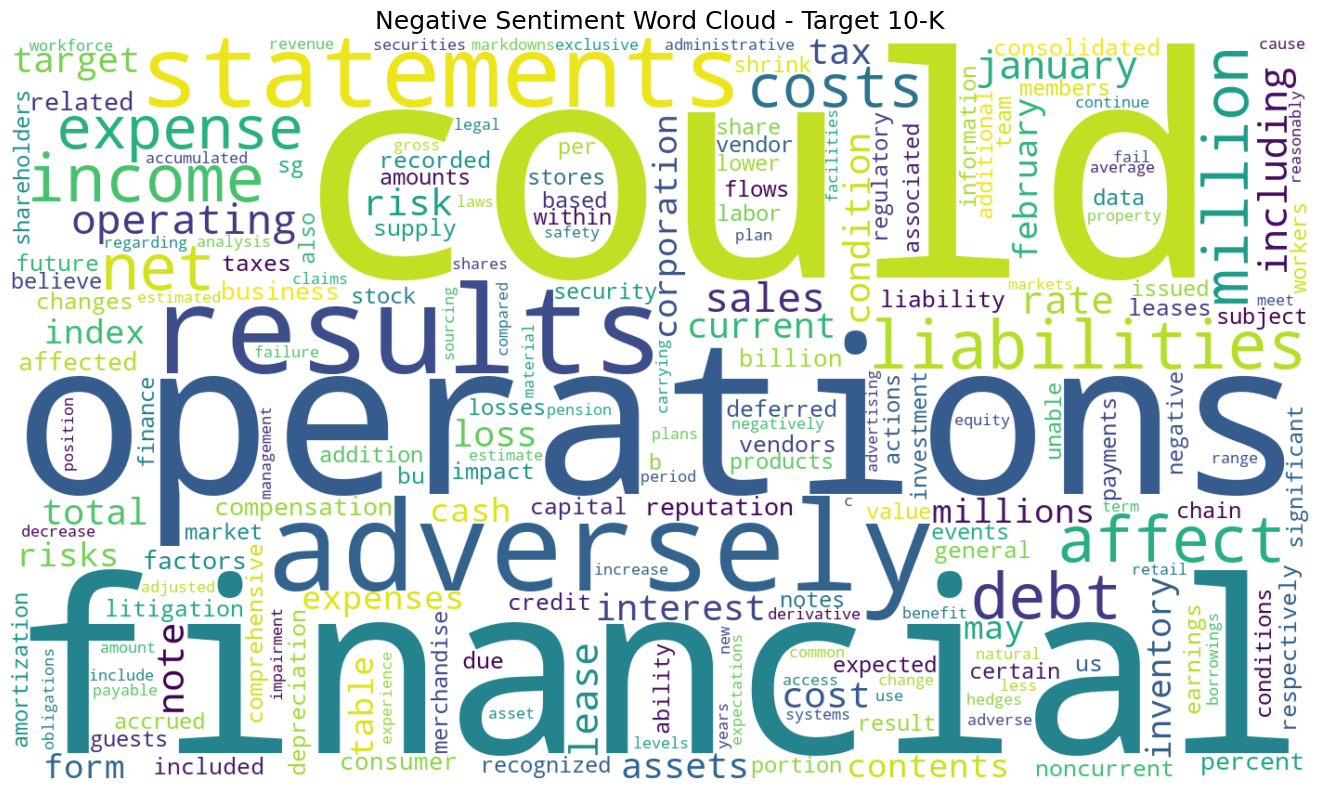

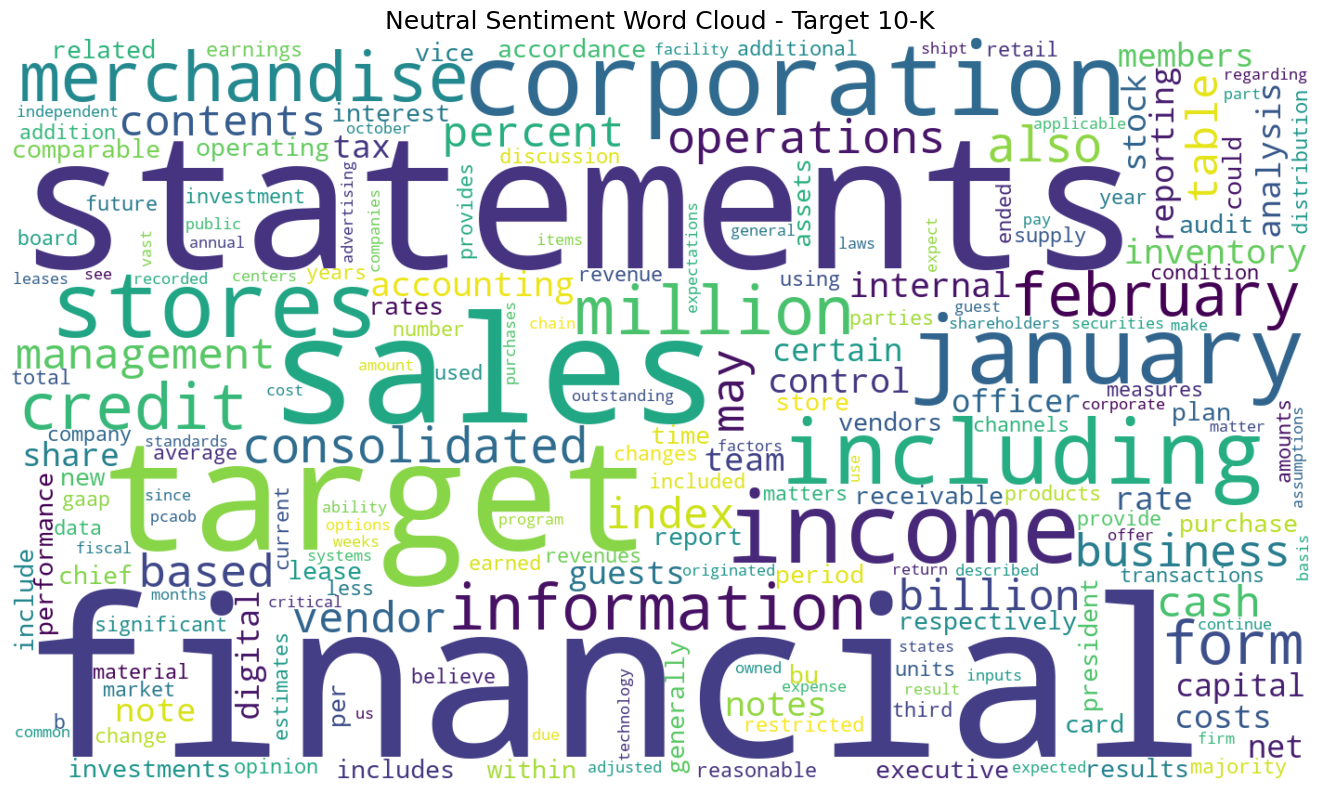


Section-level sentiment with net score:
                                                 file               section  \
12  TARGET CORP files (10-K) Basic annual filing, ...              business   
15  TARGET CORP files (10-K) Basic annual filing, ...  financial_statements   
14  TARGET CORP files (10-K) Basic annual filing, ...                  md&a   
13  TARGET CORP files (10-K) Basic annual filing, ...          risk_factors   
4   TARGET CORP files (10-K) Basic annual filing, ...              business   
7   TARGET CORP files (10-K) Basic annual filing, ...  financial_statements   
6   TARGET CORP files (10-K) Basic annual filing, ...                  md&a   
5   TARGET CORP files (10-K) Basic annual filing, ...          risk_factors   
0   TARGET CORP files (10-K) Basic annual filing, ...              business   
3   TARGET CORP files (10-K) Basic annual filing, ...  financial_statements   
2   TARGET CORP files (10-K) Basic annual filing, ...                  md&a   
1   TARGET 

In [ ]:
import re
from pathlib import Path
from collections import Counter, defaultdict

import fitz  # PyMuPDF
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

nltk.download("punkt")
nltk.download("stopwords")

# =========================================================
# 1. FILES
# =========================================================
DATA_DIR = Path("/Users/sumeyyepakdil/Desktop")

PDF_FILES = [
    DATA_DIR / "TARGET CORP files (10-K) Basic annual filing, for period end 29-Jan-22 (TGT-US).pdf",
    DATA_DIR / "TARGET CORP files (10-K) Basic annual filing, for period end 28-Jan-23 (TGT-US).pdf",
    DATA_DIR / "TARGET CORP files (10-K) Basic annual filing, for period end 3-Feb-24 (TGT-US).pdf",
    DATA_DIR / "TARGET CORP files (10-K) Basic annual filing, for period end 1-Feb-25 (TGT-US).pdf",
    DATA_DIR / "TARGET CORP files (10-K) Basic annual filing, for period end 31-Jan-26 (TGT-US).pdf",
]

# =========================================================
# 2. BASIC TEXT EXTRACTION
# =========================================================
def extract_pdf_text(pdf_path: Path) -> str:
    doc = fitz.open(pdf_path)
    text = []
    for page in doc:
        text.append(page.get_text("text"))
    return "\n".join(text)

# =========================================================
# 3. CLEANING
# =========================================================
def clean_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    text = text.replace("’", "'")
    return text.strip()

# =========================================================
# 4. SECTION EXTRACTION
#    Simple regex-based approach for main 10-K sections
# =========================================================
SECTION_PATTERNS = {
    "business": r"Item\s+1\.\s*Business(.*?)(Item\s+1A\.|Item\s+1A\s)",
    "risk_factors": r"Item\s+1A\.\s*Risk Factors(.*?)(Item\s+1B\.|Item\s+1B\s|Item\s+1C\.|Item\s+1C\s)",
    "md&a": r"Item\s+7\.\s*Management'?s Discussion and Analysis of Financial Condition and Results of Operations(.*?)(Item\s+7A\.|Item\s+7A\s)",
    "financial_statements": r"Item\s+8\.\s*Financial Statements and Supplementary Data(.*?)(Item\s+9\.|Item\s+9\s)"
}

def extract_sections(text: str) -> dict:
    sections = {}
    for name, pattern in SECTION_PATTERNS.items():
        match = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        sections[name] = match.group(1).strip() if match else ""
    return sections

# =========================================================
# 5. FINANCE-AWARE SENTIMENT LEXICON
#    This is a simple custom lexicon for SEC filings.
# =========================================================
positive_words = {
    "growth", "improve", "improved", "strong", "strength", "resilient", "benefit",
    "benefits", "expand", "expanded", "opportunity", "efficient", "efficiency",
    "gain", "gains", "profit", "profitable", "stabilize", "stabilized", "enhance",
    "value", "convenience", "innovation", "loyalty", "engagement", "recovery",
    "higher", "increase", "increased", "successful", "relevant"
}

negative_words = {
    "risk", "risks", "adverse", "adversely", "decline", "decrease", "decreased",
    "lower", "loss", "losses", "shrink", "theft", "litigation", "boycott",
    "inflation", "pressure", "pressures", "disruption", "disruptions", "tariff",
    "tariffs", "uncertainty", "volatile", "volatility", "impairment", "closure",
    "markdown", "markdowns", "expense", "expenses", "debt", "liability", "liabilities",
    "cyberattack", "breach", "breaches", "reputation", "negative", "weak", "weaker"
}

# Terms that are often neutral in finance unless surrounded by positive/negative words
neutral_finance_terms = {
    "inventory", "sales", "revenue", "margin", "capital", "assets", "cash",
    "operating", "fiscal", "quarter", "stores", "digital", "sourcing", "supply",
    "channel", "traffic", "transactions", "demand", "fulfillment", "guests",
    "merchandise", "pricing", "promotion"
}

# Context rules for finance words that can change meaning
def contextual_label(token: str, sentence: str) -> str:
    s = sentence.lower()
    token = token.lower()

    # Example contextual handling
    if token == "margin":
        if "improved margin" in s or "margin expansion" in s or "higher margin" in s:
            return "positive"
        if "margin pressure" in s or "lower margin" in s or "margin decline" in s:
            return "negative"
        return "neutral"

    if token == "inventory":
        if "excess inventory" in s or "elevated inventory" in s or "inventory markdowns" in s:
            return "negative"
        if "inventory management" in s or "improved inventory" in s:
            return "positive"
        return "neutral"

    if token == "debt":
        if "higher debt" in s or "debt levels" in s or "debt obligations" in s:
            return "negative"
        return "neutral"

    if token == "cash":
        if "increase in cash" in s or "cash provided by operating activities" in s:
            return "positive"
        return "neutral"

    return "neutral"

# =========================================================
# 6. SENTIMENT AT SENTENCE LEVEL
# =========================================================
stop_words = set(stopwords.words("english"))

def sentence_sentiment(sentence: str) -> dict:
    words = [w.lower() for w in word_tokenize(sentence) if w.isalpha()]
    pos = sum(1 for w in words if w in positive_words)
    neg = sum(1 for w in words if w in negative_words)

    # add contextual score adjustments
    for w in words:
        label = contextual_label(w, sentence)
        if label == "positive":
            pos += 1
        elif label == "negative":
            neg += 1

    if pos > neg:
        label = "positive"
    elif neg > pos:
        label = "negative"
    else:
        label = "neutral"

    return {
        "sentence": sentence,
        "positive_score": pos,
        "negative_score": neg,
        "sentiment": label
    }

# =========================================================
# 7. WORD COLLECTION FOR WORD CLOUDS
# =========================================================
def collect_words_by_sentiment(text: str):
    pos_words = []
    neg_words = []
    neu_words = []

    sentences = sent_tokenize(text)
    for sent in sentences:
        result = sentence_sentiment(sent)
        words = [w.lower() for w in word_tokenize(sent) if w.isalpha() and w.lower() not in stop_words]

        # keep finance words too
        if result["sentiment"] == "positive":
            pos_words.extend(words)
        elif result["sentiment"] == "negative":
            neg_words.extend(words)
        else:
            neu_words.extend(words)

    return pos_words, neg_words, neu_words

# =========================================================
# 8. SECTION-LEVEL ANALYSIS
# =========================================================
records = []
all_pos, all_neg, all_neu = [], [], []

for pdf_file in PDF_FILES:
    raw_text = extract_pdf_text(pdf_file)
    text = clean_text(raw_text)
    sections = extract_sections(text)

    for section_name, section_text in sections.items():
        if not section_text:
            continue

        sentences = sent_tokenize(section_text)
        results = [sentence_sentiment(s) for s in sentences]

        df_temp = pd.DataFrame(results)
        pos_count = (df_temp["sentiment"] == "positive").sum()
        neg_count = (df_temp["sentiment"] == "negative").sum()
        neu_count = (df_temp["sentiment"] == "neutral").sum()

        records.append({
            "file": pdf_file.name,
            "section": section_name,
            "positive_sentences": int(pos_count),
            "negative_sentences": int(neg_count),
            "neutral_sentences": int(neu_count),
            "avg_positive_score": df_temp["positive_score"].mean(),
            "avg_negative_score": df_temp["negative_score"].mean()
        })

        p, n, u = collect_words_by_sentiment(section_text)
        all_pos.extend(p)
        all_neg.extend(n)
        all_neu.extend(u)

summary_df = pd.DataFrame(records)
print(summary_df)

summary_df.to_csv(DATA_DIR / "target_10k_section_sentiment_summary.csv", index=False)

# =========================================================
# 9. TOP WORDS BY SENTIMENT
# =========================================================
def top_words(words, n=30):
    return Counter(words).most_common(n)

print("\nTop positive words:")
print(top_words(all_pos, 30))

print("\nTop negative words:")
print(top_words(all_neg, 30))

print("\nTop neutral words:")
print(top_words(all_neu, 30))

# =========================================================
# 10. WORD CLOUDS
# =========================================================
def make_wordcloud(words, title, out_file):
    freqs = Counter(words)
    wc = WordCloud(
        width=1400,
        height=800,
        background_color="white",
        max_words=200
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(14, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()

make_wordcloud(all_pos, "Positive Sentiment Word Cloud - Target 10-K", DATA_DIR / "target_positive_wordcloud.png")
make_wordcloud(all_neg, "Negative Sentiment Word Cloud - Target 10-K", DATA_DIR / "target_negative_wordcloud.png")
make_wordcloud(all_neu, "Neutral Sentiment Word Cloud - Target 10-K", DATA_DIR / "target_neutral_wordcloud.png")

# =========================================================
# 11. OPTIONAL: SECTION SCORE
#    Net sentiment = positive - negative
# =========================================================
summary_df["net_sentiment"] = summary_df["positive_sentences"] - summary_df["negative_sentences"]
summary_df = summary_df.sort_values(["file", "section"])
print("\nSection-level sentiment with net score:")
print(summary_df)

summary_df.to_csv(DATA_DIR / "target_10k_section_sentiment_scored.csv", index=False)

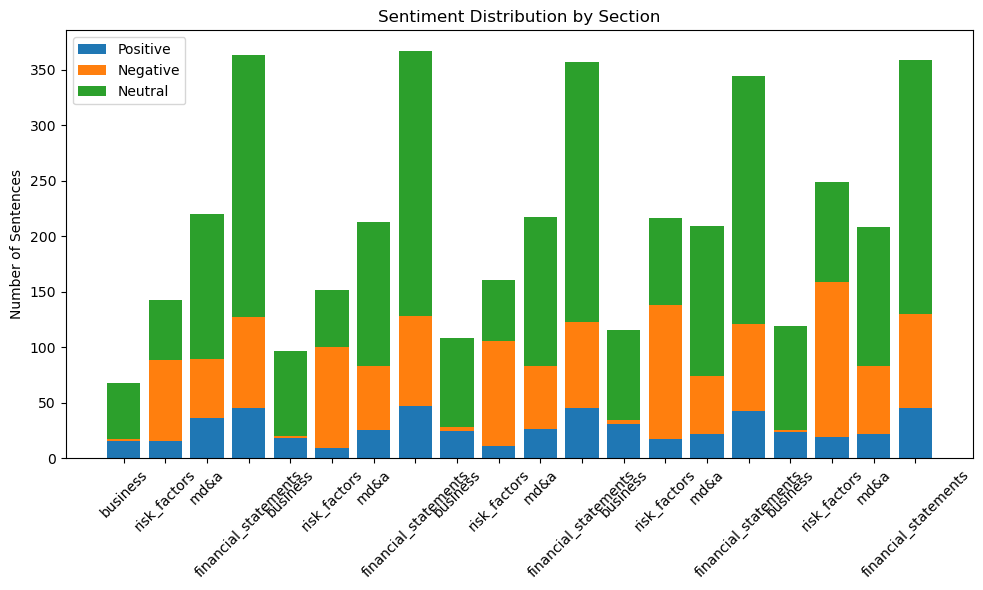

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your sentiment summary file
df = pd.read_csv("target_10k_section_sentiment_summary.csv")

# Plot
fig, ax = plt.subplots(figsize=(10,6))

sections = df["section"]
x = range(len(sections))

ax.bar(x, df["positive_sentences"], label="Positive")
ax.bar(x, df["negative_sentences"], bottom=df["positive_sentences"], label="Negative")
ax.bar(x, df["neutral_sentences"],
       bottom=df["positive_sentences"] + df["negative_sentences"],
       label="Neutral")

ax.set_xticks(x)
ax.set_xticklabels(sections, rotation=45)
ax.set_title("Sentiment Distribution by Section")
ax.set_ylabel("Number of Sentences")
ax.legend()

plt.tight_layout()
plt.show()

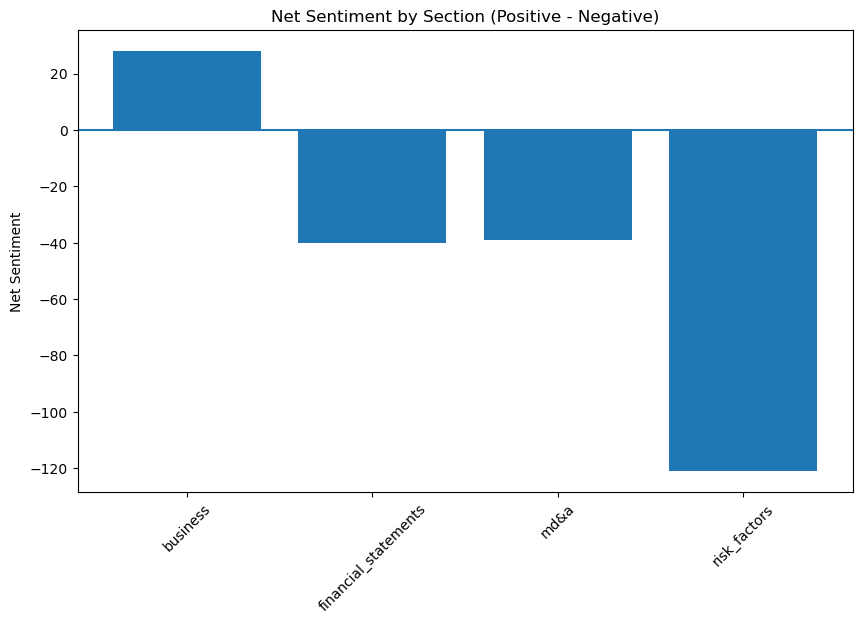

In [ ]:
df = pd.read_csv("target_10k_section_sentiment_scored.csv")

plt.figure(figsize=(10,6))
plt.bar(df["section"], df["net_sentiment"])

plt.axhline(0)
plt.title("Net Sentiment by Section (Positive - Negative)")
plt.xticks(rotation=45)
plt.ylabel("Net Sentiment")

plt.show()

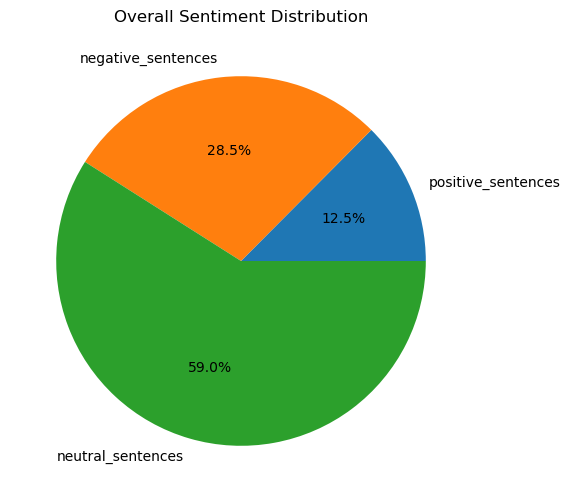

In [ ]:
totals = df[["positive_sentences","negative_sentences","neutral_sentences"]].sum()

plt.figure(figsize=(6,6))
plt.pie(totals, labels=totals.index, autopct="%1.1f%%")
plt.title("Overall Sentiment Distribution")
plt.show()

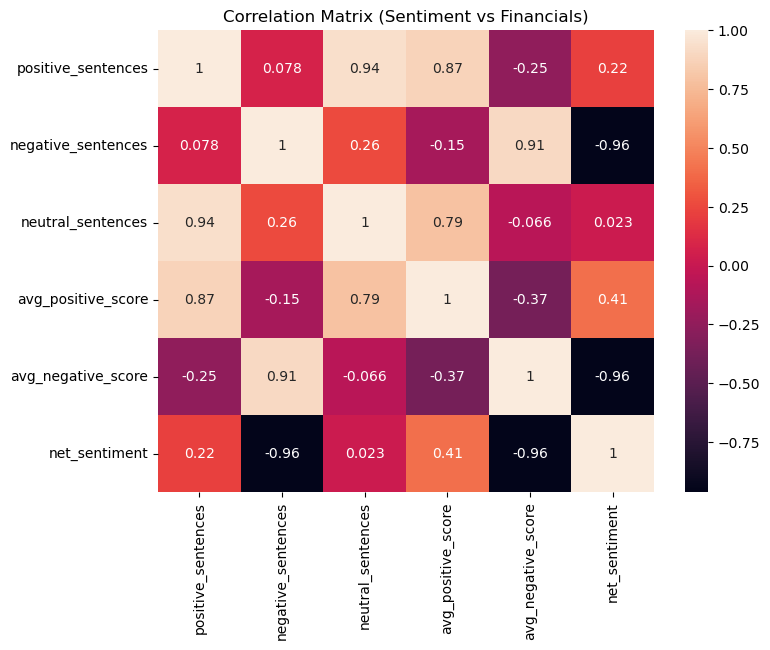

In [ ]:
# Example: merge with financial data
# df_financial = pd.read_csv("financial_data.csv")

# merged = df.merge(df_financial, on="year")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix (Sentiment vs Financials)")
plt.show()